In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

### На основе датасета, который был использован вами для промежуточной аттестации (или другого):

In [43]:
# 1. датасет Medical Insurance с Kaggle
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


где bmi - индекс массы тела

In [48]:
# Преобразуем все в числовой формат с помощью функции get_dummies

df_encoded = pd.get_dummies(df, columns = ['sex', 'smoker'], drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns = ['region'], drop_first=False)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,False,True
1,18,33.770,1,1725.55230,True,False,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,False,True,False
3,33,22.705,0,21984.47061,True,False,False,True,False,False
4,32,28.880,0,3866.85520,True,False,False,True,False,False


### Выберите вещественную переменную в качестве таргета и несколько объясняющих переменных

Целевая переменная - charges (цена страховки)
Объясняющие переменные  - все остальные

### Постройте точечные диаграммы (scatterplots) для таргета и каждой фичи, опишите форму взаимосвязи между переменными

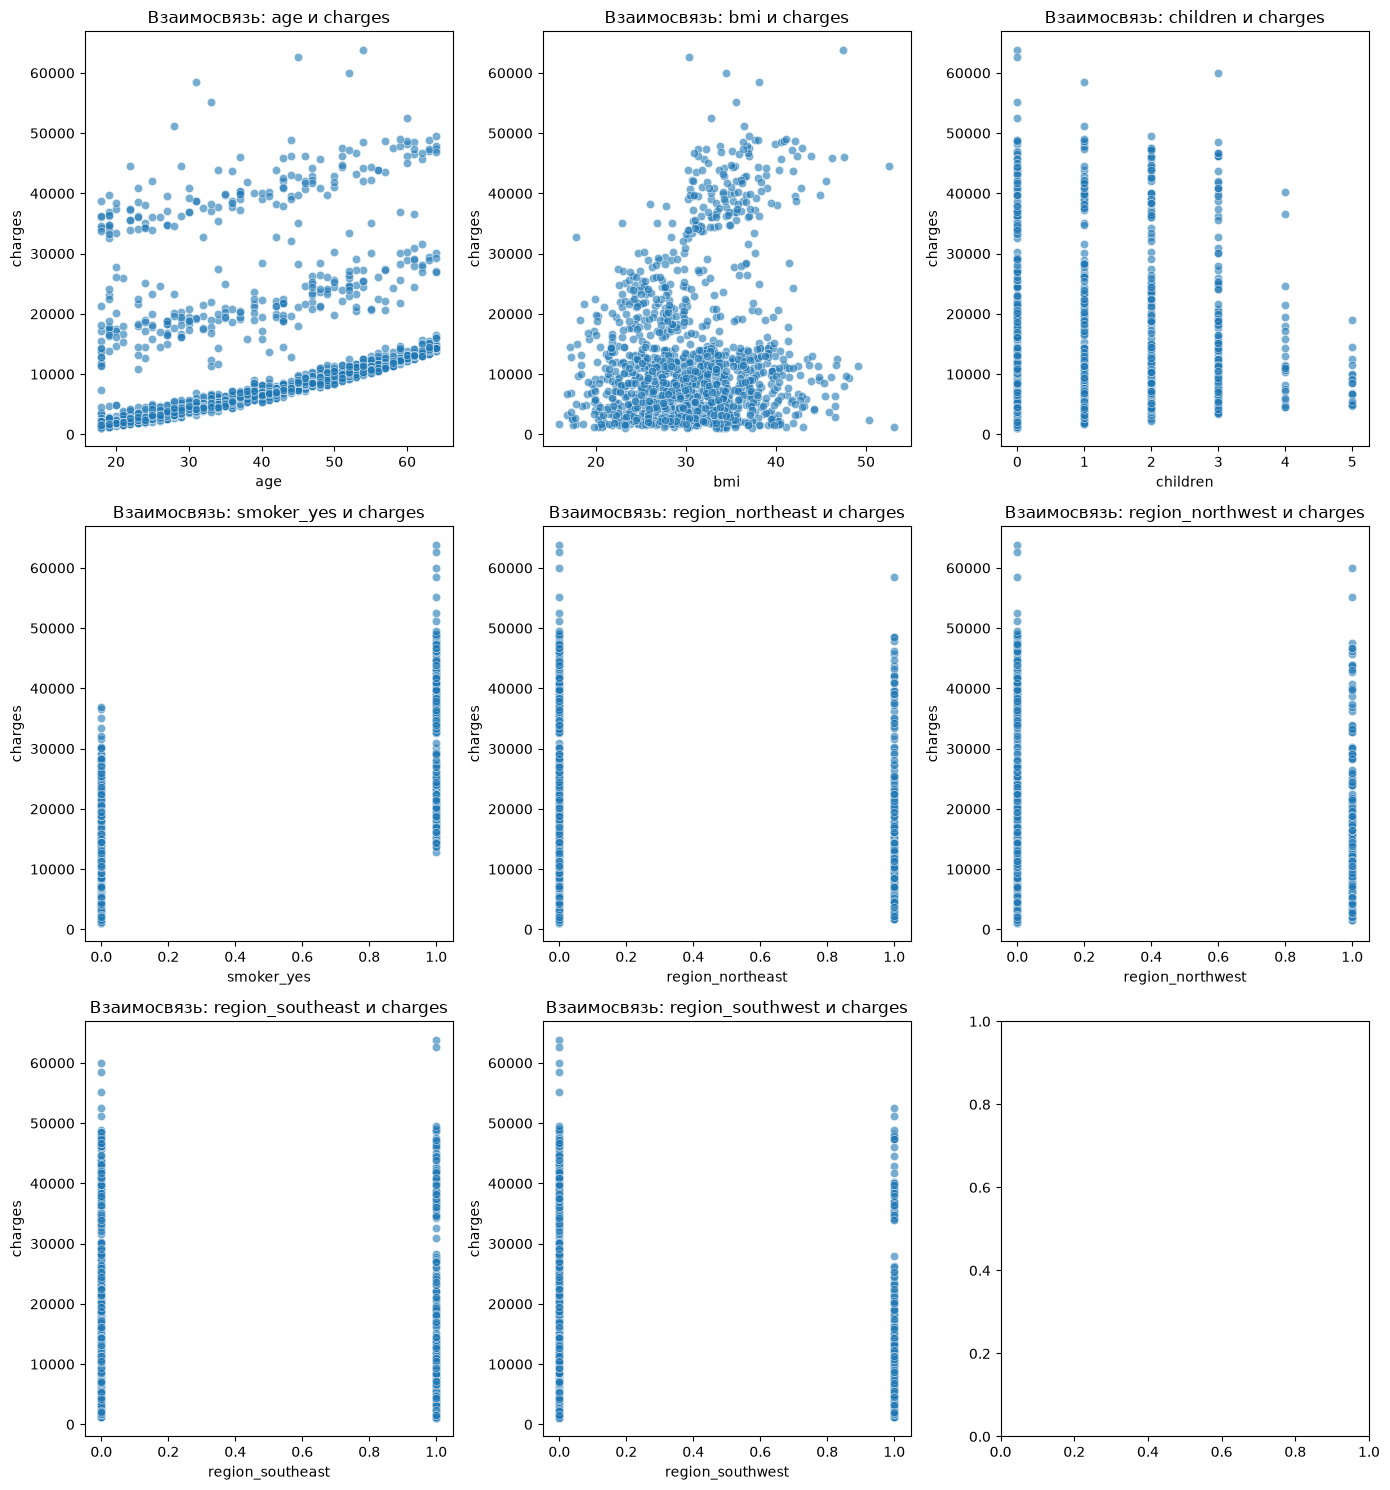

In [50]:
features_to_plot = ['age', 'bmi', 'children', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
target = 'charges'

fig, axes = plt.subplots(3, 3, figsize=(14, 15))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.scatterplot(data=df_encoded, x=feature, y=target, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Взаимосвязь: {feature} и {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

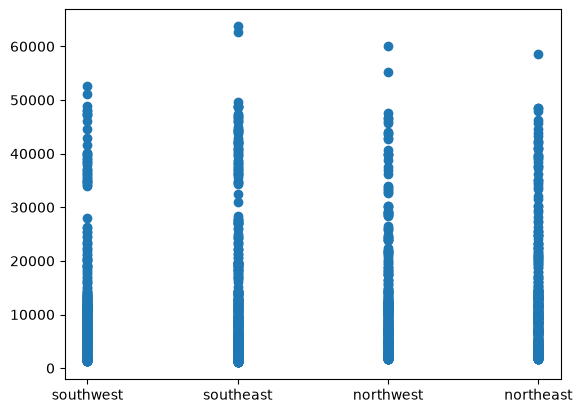

In [47]:
# Глянем отдельно на region из иригинального датафрейма
plt.scatter(data = df, x = "region", y = "charges")
plt.show()


Связи страховки с регионом не наблюдается.

Видна связь размера страховки с возрастом, курением, количеством детей.

Совсем небольшая связь наблюдается с bmi

### Разделите датасет на обучающую и тестовую выборки

In [58]:
def split_train_test(df, features_col, target_col, to_scale = False):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    if to_scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

In [59]:
target_col = ['charges']
features_col = ['age', 'bmi', 'children', 'smoker_yes']
X_train, X_test, y_train, y_test = split_train_test(df_encoded, features_col, target_col)


### Сделайте масштабирование объясняющих переменных

In [61]:
X_train_scaled, X_test_scaled, y_train, y_test = split_train_test(df_encoded, features_col, target_col, to_scale = True)


### Обучите модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающей выборке

In [ ]:
class ML_insurance:
    def __init__(self, df, features_col, show = True,
                 model_kind='linear', to_scale=False, random_state=42,
                 test_size=0.33, target_col='charges', alpha=0.1):
        self.df = df
        self.features_col = features_col
        self.model_kind = model_kind
        self.target_col = target_col
        self.test_size = test_size
        self.random_state = random_state

        if self.model_kind in ('lasso' or 'ridge'):
            to_scale = True

        # сразу готовим данные и обучаем
        self.split_train_test(to_scale=to_scale)
        self.model = self.train_model(kind=model_kind, alpha=alpha)
        self.y_pred = self.get_predictions(self.model, self.X_test)
        if show :
            self.visualize_prediction(y_test, self.y_pred)
            self.show_metrics(y_test, self.y_pred)

    def split_train_test(self, to_scale=False):
        X = self.df[self.features_col]
        y = self.df[self.target_col]
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )
        if to_scale:
            self.scaler = StandardScaler()
            self.X_train = self.scaler.fit_transform(self.X_train)
            self.X_test = self.scaler.transform(self.X_test)

    def train_model(self, kind='linear', alpha=0.1):
        if kind == 'linear':
            model = LinearRegression()
        elif kind == 'lasso':
            model = Lasso(alpha=alpha)
        elif kind == 'ridge':
            model = Ridge(alpha=alpha)
        else:
            raise ValueError(kind)
        model.fit(self.X_train, self.y_train)
        return model

    def get_predictions(self, model, X_test):
        return model.predict(X_test)

    def visualize_prediction(self, y_true, y_pred):
        fig, ax = plt.subplots(1,1, figsize = (5,5))
        sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
        sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
        ax.set_title(f"значения y ({self.model_kind}, random={self.random_state}, {self.features_col})")
        ax.set_xlabel('true y')
        ax.set_ylabel('pred y')
        plt.show()

    def show_metrics(self, y_true, y_pred):
        print('Среднее значение Y: ', np.mean(y_true))
        print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
        print('MSE: ', mean_squared_error(y_true, y_pred)),
        print('RMSE: ', root_mean_squared_error(y_true, y_pred))
        print('MAE: ', mean_absolute_error(y_true, y_pred))
        print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
        print('R2: ', r2_score(y_true, y_pred))

# features_col = ['age', 'bmi', 'children', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']



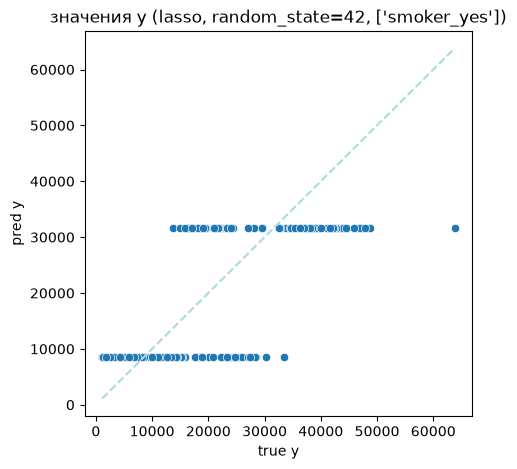

Среднее значение Y:  13048.923798052034
Среднеквадратическое отклонение Y:  12105.563015065558
MSE:  52765207.91447656
RMSE:  7263.966403727137
MAE:  5594.510909324187
MAPE:  0.8648914761298997
R2:  0.6399376859824779


In [86]:
ml = list()
ml.append (ML_insurance(df_encoded, ['smoker_yes',], model_kind='lasso' ))



In [8]:


• Сделайте предсказания целевой переменной для тестовой выборки
• Рассчитайте метрики качества
• Выберите спецификацию модели с наилучшим качеством
• Сделайте выводы относительно полученной модели и ее качества
• Разместите блокнот в GitHub и прикрепите ссылку на блокнот в удаленном репозитории


SyntaxError: invalid character '•' (U+2022) (3832814161.py, line 1)